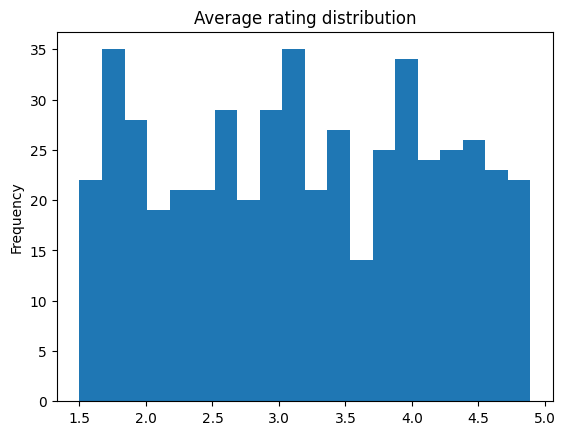

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json('../books.json')
df['average_rating'].plot(kind='hist', bins=20, title='Average rating distribution')
plt.show()


In [27]:
import json
import numpy as np
import pandas as pd

# Load raw JSON data directly into a DataFrame
df = pd.read_json("../books_dirty.json")

# Normalizing empty strings to missing values(NaN)
df = df.replace(r"^\s*$", np.nan, regex=True)

# Converts publication_year values to numbers and then clamps to range of 1800-2026
df["publication_year"] = pd.to_numeric(df["publication_year"], errors="coerce")
df["publication_year"] = df["publication_year"].clip(1800, 2026)

# Converts average_rating to numeric and ensures it can't have impossible values (Rating can only be between 0-5)
df["average_rating"] = pd.to_numeric(df["average_rating"], errors="coerce")
df.loc[(df["average_rating"] < 0) | (df["average_rating"] > 5), "average_rating"] = np.nan

# Converts page_count to numeric and ensures it can't have impossible values
df["page_count"] = pd.to_numeric(df["page_count"], errors="coerce")
df.loc[df["page_count"] <= 0, "page_count"] = np.nan

# Normalize dates in last_checkout
df["last_checkout"] = pd.to_datetime(df["last_checkout"], format="%Y-%m-%dT%H:%M:%S.%f", errors="coerce")
df["last_checkout"] = df["last_checkout"].dt.strftime("%Y-%m-%d")

# Normalize text fields
text_cols = ["genre", "language", "format", "publisher", "title", "author"]

# Converts to string dtype, trims leading/trailing spaces, collapses multiple spaces, and applies proper capitalization
for col in text_cols:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.title()
    )

# Remove duplicate books
df = df.drop_duplicates(subset=["title", "author"], keep="first")

# Drop incomplete records
required = ["book_id", "title", "author", "publication_year"]
df = df.dropna(subset=required)

# Allow to display all entries
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Show final cleaned dataframe
df

,book_id,title,author,genre,publication_year,page_count,average_rating,ratings_count,price_usd,publisher,language,format,in_print,sales_millions,last_checkout,available
0,147f7eee-98d4-4a90-94cb-37401e951324,Book Title 2,Author 19,Science Fiction,1921.0,NaN,0.87,Unknown,N/A,Old Tree Publishing,French,Audio Book,False,12.49,NaN,true
2,64f047dd-b17f-4126-9fd1-090df3aa3dfd,Book Title 18,Author 24,Fantasy,2009.0,449.0,NaN,Unknown,None,Sunshine Media,French,Audio Book,true,Unknown,NaN,true
5,585a53e3-d6d6-43e6-9ac0-029df6a3f863,Book Title 20,Author 27,Mystery,1987.0,756.0,NaN,2761,163.54,Old Tree Publishing,English,Audiobook,None,1.81,NaN,false
6,048b0217-14d1-4e38-9770-f563aa61901e,Book Title 15,Author 1,Romance,1800.0,NaN,4.16,3416,None,North Star Press,French,Paperback,true,None,NaN,False
9,3f6e2304-c05e-4023-9fd2-97ae785e356e,Book Title 3,Author 6,Romance,1868.0,158.0,NaN,None,149.86,North Star Press,English,Ebook,True,Unknown,NaN,False
12,bbfdf21b-13b0-4386-8bf8-7dcdd29dd6c9,Book Title 14,Author 10,Romance,1866.0,NaN,NaN,4824,None,Sunshine Media,Spanish,Audiobook,True,None,NaN,true
13,2fdbf6d7-29d8-4221-b243-504382bd5034,Book Title 10,Author 6,Technology,1826.0,NaN,1.93,Unknown,None,North Star Press,Spanish,Audio Book,False,8.03,NaN,True
15,adad34d4-9263-4c87-abc6-1b2ac3a2a685,Book Title 6,Author 25,Biography,1800.0,788.0,NaN,Unknown,None,Galactic Books,German,Audiobook,false,None,NaN,true
16,3337eba3-a85e-4160-a789-c4bc2f6051aa,Book Title 14,Author 25,Science Fiction,2026.0,777.0,NaN,548,N/A,Sunshine Media,French,Audio Book,True,3.37,NaN,False
18,4278e63f-ba8e-4a47-8ea4-46030b72ee2b,Book Title 6,Author 1,Mystery,2025.0,178.0,NaN,None,None,<NA>,German,Audio Book,None,10.28,NaN,true
